In [ ]:
# E-commerce Customer & Sales Analytics using Python and SQL

# Objective
#This project analyzes customer behavior, sales trends, payment methods, and business insights using the Olist E-commerce dataset through Python, SQL, Pandas, and Matplotlib.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')

In [8]:
customers.head()
orders.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [10]:
print(customers.isnull().sum())
print(orders.isnull().sum())
print(items.isnull().sum())
print(payments.isnull().sum())

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [11]:
top_states = customers['customer_state'].value_counts().head(10)

print(top_states)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64


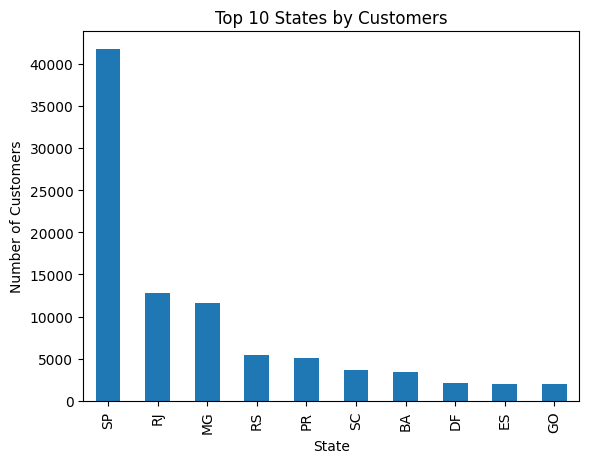

In [12]:
top_states.plot(kind='bar')

plt.title('Top 10 States by Customers')
plt.xlabel('State')
plt.ylabel('Number of Customers')

plt.show()

In [13]:
total_revenue = items['price'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 13591643.700000003


In [23]:
top_products = items['product_id'].value_counts().head(10)

print(top_products)

product_id
aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
53759a2ecddad2bb87a079a1f1519f73    373
d1c427060a0f73f6b889a5c7c61f2ac4    343
53b36df67ebb7c41585e8d54d6772e08    323
154e7e31ebfa092203795c972e5804a6    281
3dd2a17168ec895c781a9191c1e95ad7    274
Name: count, dtype: int64


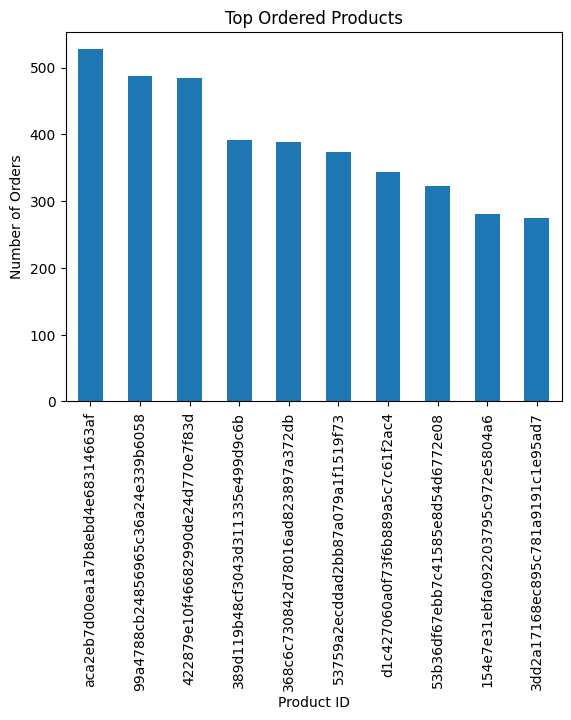

In [24]:
top_products.plot(kind='bar')

plt.title('Top Ordered Products')
plt.xlabel('Product ID')
plt.ylabel('Number of Orders')

plt.show()

In [25]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)
orders['month'] = orders['order_purchase_timestamp'].dt.month
monthly_orders = orders.groupby('month').size()

print(monthly_orders)

month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
dtype: int64


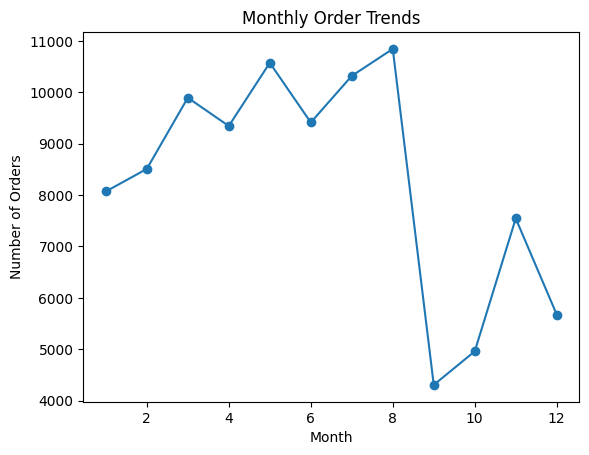

In [26]:
monthly_orders.plot(kind='line', marker='o')

plt.title('Monthly Order Trends')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.show()

In [16]:
payment_types = payments['payment_type'].value_counts()

print(payment_types)

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


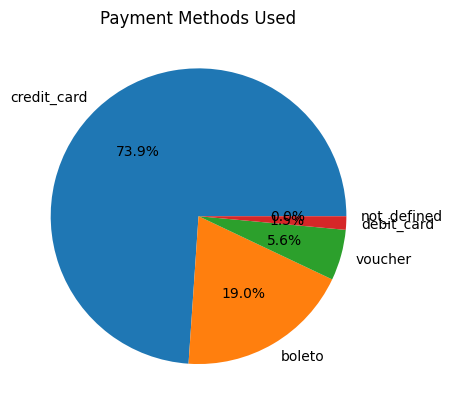

In [17]:
payment_types.plot(kind='pie', autopct='%1.1f%%')

plt.title('Payment Methods Used')

plt.ylabel('')

plt.show()

In [18]:
conn = sqlite3.connect(':memory:')

customers.to_sql('customers', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')

103886

In [19]:
query = '''
SELECT customer_state, COUNT(*) as total_customers
FROM customers
GROUP BY customer_state
ORDER BY total_customers DESC
LIMIT 10
'''

result = pd.read_sql(query, conn)

print(result)

  customer_state  total_customers
0             SP            41746
1             RJ            12852
2             MG            11635
3             RS             5466
4             PR             5045
5             SC             3637
6             BA             3380
7             DF             2140
8             ES             2033
9             GO             2020


In [20]:
query2 = '''
SELECT payment_type, COUNT(*) as total_payments
FROM payments
GROUP BY payment_type
ORDER BY total_payments DESC
'''

result2 = pd.read_sql(query2, conn)

print(result2)

  payment_type  total_payments
0  credit_card           76795
1       boleto           19784
2      voucher            5775
3   debit_card            1529
4  not_defined               3


In [ ]:
# Business Insights

#São Paulo had the highest customer concentration among all states.
# Credit card payments dominated the platform transactions.
# A small group of products contributed significantly to total revenue.
# Customer purchasing activity showed strong regional concentration.
# Revenue analysis indicated opportunities for targeted customer retention strategies.